# AI Pulse -- Gold Analysis & Manual Review

## 1. Scope and collection limitation

This notebook analyzes only the Hacker News stories `collector.py` captured via the Algolia search API, matching `config.BROAD_KEYWORDS` and `config.TRACKED_KEYWORDS` in title/text, collected by **manual** `--backfill`/incremental runs (no continuous scheduler in this MVP). Results describe the discourse in **this collected sample of HN stories**, not all of Hacker News or the wider AI-news landscape. `points`/`num_comments` reported below are HN **engagement** counts only -- this notebook never treats them as a sentiment or view-count signal.

In [1]:
import config
import pandas as pd
from db import connect, migrate

conn = connect(config.DB_PATH)
migrate(conn)

print("DB_PATH:", config.DB_PATH)
print("BROAD_KEYWORDS:", config.BROAD_KEYWORDS)
print("TRACKED_KEYWORDS:", config.TRACKED_KEYWORDS)

coverage = pd.read_sql_query(
    "SELECT MIN(created_at) AS earliest, MAX(created_at) AS latest, "
    "COUNT(*) AS story_count FROM stories",
    conn,
)
coverage

DB_PATH: ai_monitor.db
BROAD_KEYWORDS: ['artificial intelligence', 'LLM', 'machine learning', 'AI agent']
TRACKED_KEYWORDS: ['GPT', 'Claude', 'Gemini', 'DeepSeek', 'Qwen', 'Kimi', 'Moonshot AI', 'GLM-4', 'Zhipu AI', 'ERNIE Bot', 'Baidu ERNIE', 'Doubao', 'Hunyuan', 'MiniMax', 'Baichuan', 'Yi-Large', '01.AI', 'Llama', 'Mistral', 'Perplexity', 'Cohere']


,earliest,latest,story_count
0,2026-01-18T11:36:12Z,2026-07-17T11:15:09Z,33505


## 2. Version metadata

Every Gold result below carries `collection_query_version`, `prompt_version`, `catalog_version`, and `as_of`, so each figure traces back to the exact collector query, extraction prompt, and reference-data snapshot that produced it. `AS_OF` is pinned to the latest collected story's timestamp (not wall-clock `now()`), so re-running this notebook against the same database reproduces the same windows and figures.

In [2]:
as_of_row = pd.read_sql_query("SELECT MAX(created_at) AS as_of FROM stories", conn).iloc[0]
AS_OF = as_of_row["as_of"] or "2026-07-14T00:00:00Z"  # fallback for an empty database

catalog_versions = pd.read_sql_query(
    "SELECT DISTINCT catalog_version FROM model_catalog", conn
)["catalog_version"].tolist()

print("AS_OF:", AS_OF)
print("config.PROMPT_VERSION:", config.PROMPT_VERSION)
print("config.COLLECTION_QUERY_VERSION:", config.COLLECTION_QUERY_VERSION)
print("model_catalog catalog_version(s) present:", catalog_versions)

AS_OF: 2026-07-17T11:15:09Z
config.PROMPT_VERSION: schema-free-v2
config.COLLECTION_QUERY_VERSION: v2
model_catalog catalog_version(s) present: ['2026-07-17c']


## 3. Dataset counts and the two Gold paths

Two independent paths feed the figures below, and it matters which one a figure rests on.

- **Candidate path** (Sections 4-6): `candidate_selection.py` matches every collected story against the versioned catalog aliases, offline and deterministically. It reads no LLM output, so trend and co-occurrence cover the **whole collection**.
- **Extraction path** (Sections 7-9): session-authored Silver extractions. Only these carry `stance`, so framing and the manual review rest on the **extracted sample only**, not the full collection.

The counts below show how far apart those two denominators are — read every framing figure against the extraction count, not the story count.

In [3]:
from db import catalog_version, latest_successful_extractions

story_count = pd.read_sql_query("SELECT COUNT(*) AS n FROM stories", conn).iloc[0]["n"]
extraction_status_counts = pd.read_sql_query(
    "SELECT status, COUNT(*) AS n FROM story_extractions GROUP BY status", conn
)
latest_success = latest_successful_extractions(conn)

CATALOG_VERSION = catalog_version(conn)
candidate_count = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM story_candidates WHERE catalog_version = ?",
    conn,
    params=(CATALOG_VERSION,),
).iloc[0]["n"]

print("Total collected stories:", story_count)
print(f"Candidate stories (catalog {CATALOG_VERSION}):", candidate_count)
print("Stories with a latest successful extraction:", len(latest_success))
print(f"  -> trend/co-occurrence rest on {candidate_count} stories,"
      f" framing/review on {len(latest_success)}")
extraction_status_counts

Total collected stories: 33505
Candidate stories (catalog 2026-07-17c): 11204
Stories with a latest successful extraction: 11037
  -> trend/co-occurrence rest on 11204 stories, framing/review on 11037


,status,n
0,succeeded,11037


## 4. Family trend (`candidate_emerging_models`, `group_level="family"`)

Mention counts are per distinct story (a family mentioned twice in one story counts once). `mention_delta`/`mention_growth` compare the most recent window to the prior window of equal length; `points_sum`/`comments_sum` are engagement totals shown as context only -- they are not part of the ranking.

This runs on the **candidate path**, so it covers every collected story rather than the extracted sample. That is not only for coverage: the extraction sample is drawn by a fixed seed across the whole collection, so it scatters across months and leaves the 24-hour window nearly empty. A trend needs density in the recent window, which only the full candidate set provides.

In [4]:
from analysis import candidate_emerging_models

family_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="family")
family_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,resolved,Anthropic/Claude,51,29,22,0.758621,597,472,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Moonshot AI,Kimi,None,resolved,Moonshot AI/Kimi,17,0,17,17.000000,1938,1020,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,Anysphere,Cursor,None,resolved,Anysphere/Cursor,7,3,4,1.333333,14,4,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,xAI,Grok,None,resolved,xAI/Grok,3,2,1,0.500000,7,0,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Google,Gemini,None,resolved,Google/Gemini,5,5,0,0.000000,357,165,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
5,OpenAI,GPT,None,resolved,OpenAI/GPT,22,23,-1,-0.043478,422,424,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


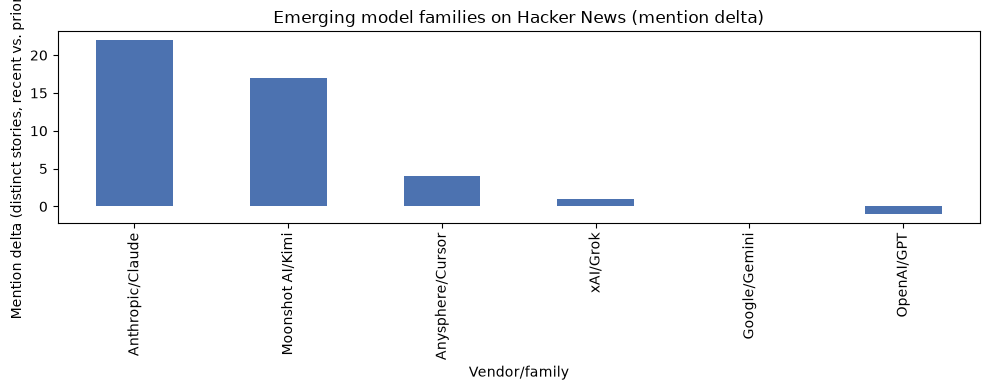

In [5]:
import matplotlib.pyplot as plt

if not family_trend.empty:
    ax = family_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#4C72B0"
    )
    ax.set_ylabel("Mention delta (distinct stories, recent vs. prior window)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Emerging model families on Hacker News (mention delta)")
    plt.tight_layout()
    plt.show()
else:
    print("No family-level mentions in the current window/thresholds.")

## 5. Version trend (`candidate_emerging_models`, `group_level="version"`)

Same computation as Section 4, one level more specific: mentions without a resolved version are labeled `"unresolved version"` rather than dropped.

Expect most rows to be unresolved here. Version aliases (`Claude Opus 4.6`, `Gemini 2.0 Flash`, ...) attach to their **family** record in the catalog, because a version record requires a sourced release and many surfaces name rumored or unreleased versions. Version-level trend therefore stays thin until those records exist.

In [6]:
version_trend = candidate_emerging_models(conn, as_of=AS_OF, group_level="version")
version_trend

,vendor,family,version,resolution_status,group_label,recent_story_count,previous_story_count,mention_delta,mention_growth,points_sum,comments_sum,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,unresolved version,resolved,Anthropic/Claude/unresolved version,51,29,22,0.758621,597,472,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Moonshot AI,Kimi,unresolved version,resolved,Moonshot AI/Kimi/unresolved version,17,0,17,17.000000,1938,1020,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,OpenAI,GPT,5.6 Sol,resolved,OpenAI/GPT/5.6 Sol,6,1,5,5.000000,329,394,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,Anysphere,Cursor,unresolved version,resolved,Anysphere/Cursor/unresolved version,7,3,4,1.333333,14,4,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Anthropic,Claude,Opus 4.8,resolved,Anthropic/Claude/Opus 4.8,2,0,2,2.000000,13,5,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
5,xAI,Grok,unresolved version,resolved,xAI/Grok/unresolved version,3,2,1,0.500000,7,0,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
6,Google,Gemini,unresolved version,resolved,Google/Gemini/unresolved version,5,5,0,0.000000,357,165,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
7,OpenAI,GPT,unresolved version,resolved,OpenAI/GPT/unresolved version,22,23,-1,-0.043478,422,424,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


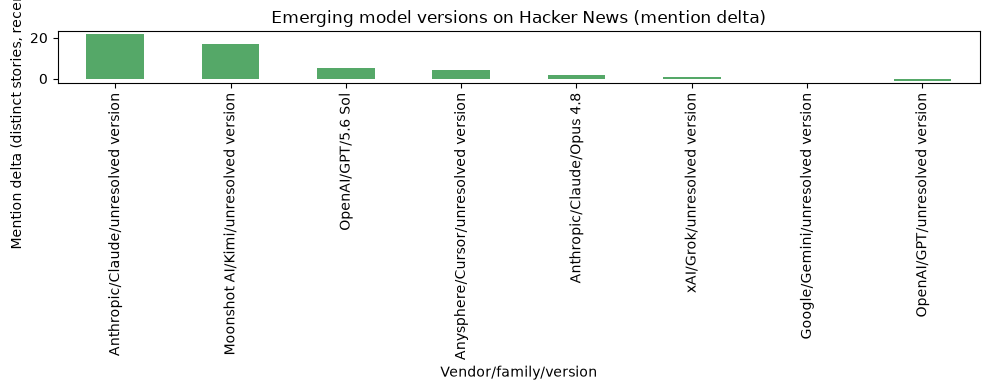

In [7]:
if not version_trend.empty:
    ax = version_trend.set_index("group_label")["mention_delta"].plot(
        kind="bar", figsize=(10, 4), color="#55A868"
    )
    ax.set_ylabel("Mention delta (distinct stories, recent vs. prior window)")
    ax.set_xlabel("Vendor/family/version")
    ax.set_title("Emerging model versions on Hacker News (mention delta)")
    plt.tight_layout()
    plt.show()
else:
    print("No version-level mentions in the current window/thresholds.")

## 5b. Model lineup by vendor (recency-weighted)

Family/version trend above only looks at the most recent 24h window. This section
looks at the **full collected history** per resolved `model_id`, so a vendor's actual
lineup (not just the family total) is visible -- e.g. Anthropic ships Opus 4.7, Opus 4.8,
Sonnet 4.6, and Mythos as distinct catalog entries, not one "Claude" blob.

`story_count` is a flat lifetime count, so a months-old launch spike counts exactly as
much as something trending today. `weighted_count` decays each story's contribution by
`0.5 ** (age_days / half_life_days)` relative to `AS_OF` (default half-life: 30 days),
so recent mentions dominate the ranking instead of raw historical volume.

In [8]:
from analysis import candidate_model_lineup

lineup = candidate_model_lineup(conn, as_of=AS_OF, half_life_days=30.0)
lineup

,vendor,family,version,model_id,story_count,weighted_count,points_sum,comments_sum,as_of,half_life_days,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,anthropic-claude,8183,1562.359340,158525,90608,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
1,Anthropic,Claude,Mythos,anthropic-claude-mythos,143,38.188587,10213,6114,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
2,Anthropic,Claude,Opus 4.8,anthropic-claude-opus-4-8,62,30.859986,2497,1681,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
3,Anthropic,Claude,Opus 4.7,anthropic-claude-opus-4-7,104,18.835989,3741,2214,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
4,Anthropic,Claude,Sonnet 4.6,anthropic-claude-sonnet-4-6,63,7.681421,3438,2128,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Alibaba,Qwen,3.6,alibaba-qwen-3-6,58,18.842195,5830,2650,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
57,Alibaba,Qwen,3.5,alibaba-qwen-3-5,96,11.728813,3346,1327,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
58,Alibaba,Qwen,3.7,alibaba-qwen-3-7,4,1.134514,263,98,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match
59,Alibaba,Qwen,3.5 Flash,alibaba-qwen-3-5-flash,1,0.062489,5,2,2026-07-17T11:15:09Z,30.0,v2,2026-07-17c,catalog_alias_match


## 6. Model co-occurrence

Pairs of distinct, resolved model families mentioned in the same story (counted once per story pair), visualized as an undirected graph where edge width is the shared-story count.

Also on the **candidate path**, so every collected story contributes. Candidate mentions are all catalog-resolved by construction, so no `unresolved` pairs appear here.

In [9]:
from analysis import candidate_model_cooccurrence

cooccurrence = candidate_model_cooccurrence(conn, as_of=AS_OF, group_level="family")
cooccurrence

,vendor_a,family_a,version_a,vendor_b,family_b,version_b,story_count,as_of,collection_query_version,catalog_version,candidate_reason
0,Anthropic,Claude,None,Anysphere,Cursor,None,669,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
1,Anthropic,Claude,None,DeepSeek,DeepSeek,None,83,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
2,Anthropic,Claude,None,Google,Gemini,None,606,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
3,Anthropic,Claude,None,OpenAI,GPT,None,1642,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
4,Anysphere,Cursor,None,DeepSeek,DeepSeek,None,8,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
...,...,...,...,...,...,...,...,...,...,...,...
114,Alibaba,Qwen,None,Xiaomi,Mimo,None,2,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
115,Microsoft,Copilot,None,Mistral AI,Mistral,None,2,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
116,GitHub,Copilot,None,Moonshot AI,Kimi,None,3,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match
117,Microsoft,Copilot,None,Moonshot AI,Kimi,None,3,2026-07-17T11:15:09Z,v2,2026-07-17c,catalog_alias_match


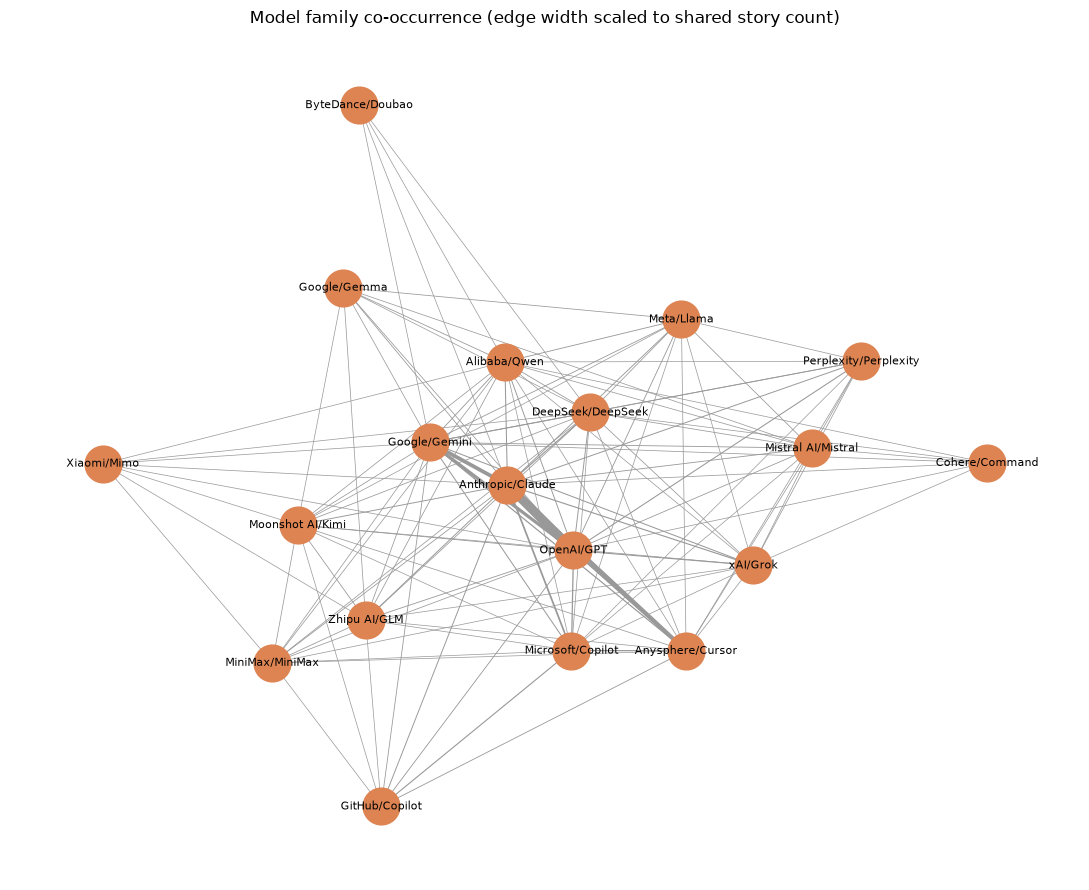

In [10]:
import networkx as nx

if not cooccurrence.empty:
    edges = cooccurrence.assign(
        label_a=cooccurrence["vendor_a"] + "/" + cooccurrence["family_a"],
        label_b=cooccurrence["vendor_b"] + "/" + cooccurrence["family_b"],
    )
    graph = nx.from_pandas_edgelist(edges, "label_a", "label_b", edge_attr="story_count")

    pos = nx.spring_layout(graph, seed=20260714, k=0.6)
    weights = [graph[u][v]["story_count"] for u, v in graph.edges()]
    max_weight = max(weights)
    scaled_widths = [0.5 + 6 * (w / max_weight) for w in weights]
    plt.figure(figsize=(11, 9))
    nx.draw_networkx(
        graph, pos, with_labels=True, node_color="#DD8452", node_size=700,
        font_size=8, width=scaled_widths, edge_color="#999999",
    )
    plt.title("Model family co-occurrence (edge width scaled to shared story count)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No co-occurring model family pairs at the current min_count threshold.")

## 7. Model framing

`stance` describes how a *story* evaluates a model, always in the direction story → entity, never the entity's own posture. This is **not** a measure of community sentiment or vote counts.

Since `schema-free-v2` the extraction contract defines each attribute slot rather than leaving the vocabulary entirely open: `kind` names what the surface denotes, `role` its position in the story's claim, `stance` the story's evaluation, and `extensions.framing` the story's own genre. `stance` is set only when `kind` is `model` or `product`. The slot vocabularies are still open — anchors (`positive`/`negative`/`neutral`/`mixed`) are preferred, a sharper label is allowed when none fits, and `unresolved` is used when the story cannot answer. Labels are stored verbatim; the contract constrains which question each slot answers, not which words may fill it.

Under `schema-free-v1` no slot was defined, and story genre leaked into `stance` (e.g. `"product launch"`), which made stance counts uninterpretable across sessions. v1 rows are retained as history under their own `prompt_version` and are not mixed into these figures.

In [11]:
from analysis import model_framing_sentiment

framing = model_framing_sentiment(conn, as_of=AS_OF, group_level="family")
framing

,vendor,family,version,resolution_status,group_label,stance,story_count,as_of,collection_query_version,prompt_version,catalog_version
0,Alibaba,Qwen,None,resolved,Alibaba/Qwen,negative,5,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
1,Alibaba,Qwen,None,resolved,Alibaba/Qwen,neutral,60,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
2,Alibaba,Qwen,None,resolved,Alibaba/Qwen,positive,16,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
3,Anthropic,Claude,None,resolved,Anthropic/Claude,mixed,2,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
4,Anthropic,Claude,None,resolved,Anthropic/Claude,negative,843,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
...,...,...,...,...,...,...,...,...,...,...,...
514,None,None,None,unresolved,mistral.rs,positive,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
515,None,None,None,unresolved,o3,negative,2,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
516,None,None,None,unresolved,qwen3-8b,neutral,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c
517,None,None,None,unresolved,superglue,positive,1,2026-07-17T11:15:09Z,v2,schema-free-v2,2026-07-17c


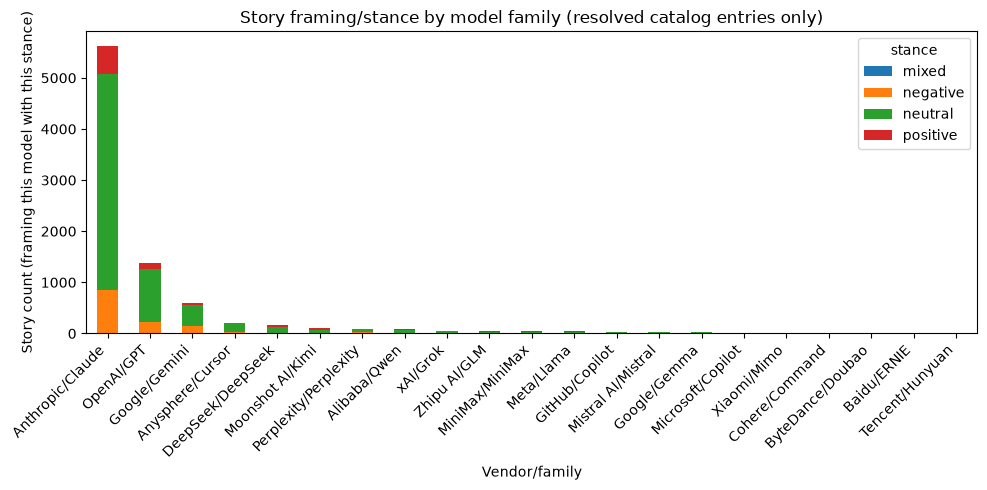

In [12]:
if not framing.empty:
    resolved_framing = framing[framing["resolution_status"] == "resolved"]
    pivot = resolved_framing.pivot_table(
        index="group_label", columns="stance", values="story_count", fill_value=0
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_ylabel("Story count (framing this model with this stance)")
    ax.set_xlabel("Vendor/family")
    ax.set_title("Story framing/stance by model family (resolved catalog entries only)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No framed (stance-labeled) observations available.")

## 8. Fixed-seed 30-story review

A fixed-seed sample of 30 stories (`seed=20260714`) drawn from the latest successful extractions, including both title-only and self-post stories when both exist. The same seed always returns the same `story_id`s in the same order (see `tests/test_analysis.py::test_review_sample_is_reproducible`). Reviewer columns (`is_relevant`, `expected_mentions`, ...) start empty and match the header of `data/manual_review_template.csv` -- a human fills them in by hand.

In [13]:
from analysis import review_sample

REVIEW_SEED = 20260714
REVIEW_SAMPLE_SIZE = 30

review = review_sample(conn, sample_size=REVIEW_SAMPLE_SIZE, seed=REVIEW_SEED)
review

,story_id,title,normalized_text,parsed_json,is_relevant,expected_mentions,extracted_mentions,evidence_valid,family_version_mapping_valid,stance_valid,error_type,reviewer_notes
0,46823036,"Chat Memo – Auto-Save AI Chats from ChatGPT, G...",,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
1,47085076,Ask HN: What Is the Point of WebMCP?,"So I have a question that should be simple, bu...","{""relevant"": false, ""observations"": [], ""exten...",None,None,None,None,None,None,None,None
2,47543189,Claude loses its >99% uptime in Q1 2026,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
3,47297392,Cursor went from $0 to $29B to existential thr...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
4,47545960,Show HN: Control Codex via WhatsApp using a Co...,"Codex plugins were released just yesterday, an...","{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
5,48867766,"Show HN: I made Claude explain like I'm 5, and...",I was burning out reading AI output. So I crea...,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
6,48111970,Can Claude Skills Replace Open Source Software?,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
7,48479452,Claude Desktop spawns 1.8 GB Hyper-V VM on eve...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
8,47557794,Who Wins If AI Models Commoditize? – With Mist...,,"{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None
9,48613373,"Never coded before, now shipping websites to c...","Claude Plans, then executes, then uses Cloudfl...","{""relevant"": true, ""observations"": [{""surface""...",None,None,None,None,None,None,None,None


In [14]:
# Export for hand annotation. This is local reviewer working data (like
# ai_monitor.db) rather than the versioned template -- decide at review time
# whether the completed copy is worth committing.
review_export_path = "data/manual_review_sample.csv"
review.to_csv(review_export_path, index=False)
print(f"Wrote {len(review)} rows to {review_export_path} for manual annotation.")

Wrote 30 rows to data/manual_review_sample.csv for manual annotation.


## 9. Precision / recall / evidence-validity calculations

Once a reviewer hand-fills `expected_mentions` (ground-truth mention count per story) and `extracted_mentions` (how many of those the LLM correctly extracted, i.e. true positives) in a completed review CSV, this section computes:

- **recall** = sum(extracted_mentions) / sum(expected_mentions) -- the share of true mentions the extraction step found.
- **precision** = sum(extracted_mentions) / sum(LLM-produced, evidence-verified observations for the same stories) -- the share of the LLM's own output that was correct. The denominator is recomputed independently from `story_extractions.parsed_json` for the reviewed stories (same `evidence_verified` filter Gold uses), not taken from the CSV, so precision does not depend on the reviewer manually counting false positives.
- **evidence / mapping / stance validity rates** = mean of the corresponding yes/no reviewer columns.

This cell expects a completed copy of `data/manual_review_template.csv` (or `data/manual_review_sample.csv` from Section 8) with reviewer columns filled in; it reports what is available and does not fabricate missing labels.

In [15]:
import json
from pathlib import Path

# Prefer the Section-8 export when present, else fall back to the versioned template.
_sample_path = Path("data/manual_review_sample.csv")
_template_path = Path("data/manual_review_template.csv")
completed_review_path = _sample_path if _sample_path.exists() else _template_path
if not completed_review_path.exists():
    print(f"{completed_review_path} not found -- nothing to score yet.")
else:
    completed = pd.read_csv(completed_review_path)
    completed = completed.dropna(subset=["expected_mentions", "extracted_mentions"])
    if completed.empty:
        print("Manual review columns are not filled in yet -- nothing to score.")
    else:
        reviewed_ids = tuple(completed["story_id"])
        placeholders = ",".join("?" for _ in reviewed_ids)
        parsed = pd.read_sql_query(
            f"SELECT story_id, parsed_json FROM story_extractions "
            f"WHERE status = 'succeeded' AND story_id IN ({placeholders})",
            conn,
            params=reviewed_ids,
        )

        def _observation_count(raw_json: str) -> int:
            envelope = json.loads(raw_json)
            return sum(
                1 for obs in envelope.get("observations", [])
                if obs.get("evidence_verified") is True
            )

        parsed["llm_observation_count"] = parsed["parsed_json"].apply(_observation_count)
        llm_counts = parsed.groupby("story_id")["llm_observation_count"].sum()

        expected_total = completed["expected_mentions"].astype(float).sum()
        extracted_total = completed["extracted_mentions"].astype(float).sum()
        llm_total = completed["story_id"].map(llm_counts).fillna(0).sum()

        recall = extracted_total / expected_total if expected_total else float("nan")
        precision = extracted_total / llm_total if llm_total else float("nan")

        def _validity_rate(column: str) -> float:
            if column not in completed.columns:
                return float("nan")
            values = completed[column].astype(str).str.strip().str.lower()
            return values.isin(["y", "yes", "true", "1"]).mean()

        print(f"Reviewed stories with counts filled in: {len(completed)}")
        print(f"Recall (extracted/expected mentions): {recall:.2f}")
        print(f"Precision (extracted/LLM-produced observations): {precision:.2f}")
        print(f"Evidence validity rate: {_validity_rate('evidence_valid'):.2f}")
        print(f"Family/version mapping validity rate: {_validity_rate('family_version_mapping_valid'):.2f}")
        print(f"Stance validity rate: {_validity_rate('stance_valid'):.2f}")

Manual review columns are not filled in yet -- nothing to score.


## 10. Limitations and Phase 2

- **Collection coverage**: only stories matching the configured Algolia `BROAD_KEYWORDS`/`TRACKED_KEYWORDS` are collected, and collection runs are triggered manually (`collector.py --backfill N` / incremental runs) rather than on a continuous schedule -- gaps between runs are possible.
- **Two different denominators**: trend and co-occurrence (Sections 4-6) rest on every collected story via catalog alias matching; framing and the manual review (Sections 7-9) rest only on the far smaller extracted sample. Do not read a framing count as a share of the collection.
- **Catalog-bound recall**: the candidate path can only see model families present in the versioned catalog. Surfaces outside it (Grok, Mistral, Llama, Gemma, ...) stay `unresolved` and never reach a family figure, so a family's absence here means "not catalogued", not "not discussed".
- **Alias precision**: matching is lexical, so a name that is not the model still matches -- the Gemini crypto exchange is a real example in this data. The extraction step catches these (`relevant: false`), but the candidate path alone does not, which inflates candidate counts relative to extraction-verified ones.
- **Engagement vs. sentiment**: `points`/`num_comments` shown alongside trend figures are Hacker News engagement counts only. They are never used as, or relabeled to, a sentiment/opinion signal; the only tone signal in this notebook is the open-world `stance` field from `model_framing_sentiment`, which describes how a *story* frames a model, not how HN commenters feel or how many viewed it.
- **Extraction noise**: a single session-authored extraction (`config.SESSION_EXTRACTION_MODEL`) and prompt version per story; only evidence-verified observations feed Gold, and only a fixed 30-story sample is manually reviewed for precision/recall/evidence validity, not the full dataset.
- **Reference data**: model release dates and benchmark scores are limited to what `reference_data.py`/`data/model_catalog.json` currently source; unlisted or unresolved surfaces stay `unresolved` rather than being force-matched.
- **Out of scope for this MVP** (explicit Phase 2 per `docs/superpowers/specs/2026-07-14-ai-pulse-design.md`): Reddit or other platforms, HN comment text, Supabase, a formal ontology, a hosted MCP server, and automated/scheduled collection.